# Paper-exact reproduction: the addition circuit on Qwen3-4B

Reproduces the biology paper's Addition dive (+ the methods-supplement interventions)
on Qwen3-4B with `mwhanna/qwen3-4b-transcoders`. Paper values:
`notes/biology_digest.md` §A; verdicts: the Summary below and `DEVLOG.md`.

**Setup facts**
- Paper format throughout: raw `calc: a+b=` completions (one sink token prepended,
  `n_bos_tokens=1`). Chat is used only for the §G introspection dialogue.
- Qwen3 emits digits one token at a time → the paper's single-token "95" circuit
  splits into two per-digit circuits: **first/magnitude** (`…=` → `9`) and **ones**
  (`…=9`, teacher-forced → `5`). Every experiment reads at its matching moment.
- The studied pair must be answered correctly (paper: 36+59; Qwen3-4B fails it) —
  §0 auto-selects the nearest same-digit-class pair: **46+49**.
- Steering: paper multiples are multiplicative M, ours additive `m = M−1`
  (ablation m=−1, paper −1× ⇒ m=−2, paper −2× ⇒ m=−3).

**v2 pipeline** — interventions run the paper's **constrained patching** only
(activations ≤ ℓ pinned at perturbed values, real model after ℓ; ℓ swept per
experiment and stated per result). Supernodes load from the **reviewed artifact**
`supernodes/addition_4b.json` (grid-evidenced scan by `build_supernodes.py` — never
influence); graphs load from the `build_supernode_inputs.py` dumps. v1 (propagate
mode, influence-pool selection) lives in git history and `DEVLOG.md`.

## Exact model inputs & artifacts

| used by | exact input (raw + sink token, except §G) | predicts |
|---|---|---|
| §0 accuracy grid | `<|endoftext|>calc: {a}+{b}=`, all a,b ∈ 0–99 | a+b |
| first-digit graph + §C magnitude readout | `<|endoftext|>calc: 46+49=` | `9` |
| ones graph + §C/§D/§E interventions | `<|endoftext|>calc: 46+49=9` (forced `9`) | `5` |
| §E polymer (bare / ones moment) | `<|endoftext|>K. Whang, etc. Polymer, 36, 837, 1` (+`99`) | `995.` / `5` |
| §E donor graph | `<|endoftext|>calc: 49+49=9` | `8` |
| §F intermediate | `<|endoftext|>assert (4 + 5) * 3 ==` | ` 27` |
| §G introspection | chat, two turns: answer 46+49, then "how did you get that?" | explanation |
| §H corpus | streamed C4 documents | (activations) |

**Artifacts** (`artifacts/paper_addition/4b/`): `interventions_constrained.json`
(§C ladders + ℓ curves), `steer_compare.json` (§D), `polymer_suppression_constrained.json`
and `lookup_swap.json` (§E; the latter holds the p(`8`)-by-ℓ curve),
`grids_supernodes.png` (§B evidence figure), `graph_*.html` explorers with the reviewed
supernodes pre-loaded, plus per-section JSONs (`accuracy_calc.npy`, `polymer_probe`,
`computed9_screen`, `introspection*`, `corpus_examples`).

In [1]:
%matplotlib inline
import json

import addition_helper as A
import matplotlib.pyplot as plt
import numpy as np
import torch

from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.settings import artifacts_dir, default_device
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder

SIZE = "4b"
DEVICE = default_device()
OUT = artifacts_dir() / "paper_addition" / SIZE
OUT.mkdir(parents=True, exist_ok=True)

model, tokenizer = load_qwen3(SIZE, dtype_str="bf16", device_map=DEVICE)
model.eval()
# Eager decoders (lazy_decoder=False): graph builds and interventions decode every
# layer repeatedly, and lazy mode re-streams ~28 GB of W_dec per clean forward — the
# notebooks' dominant cost. Eager fits an A100-80GB for the 4b (CLAUDE.md perf notes).
# (The 8b encode-only case that must stay lazy lives in multilingual.ipynb section H.)
tc = load_transcoder(
    f"qwen3-{SIZE}", device=DEVICE, dtype=torch.bfloat16, lazy_decoder=False
).transcoder
N_LAYERS = len(tc)
A_VALS = list(range(100))
B_VALS = list(range(100))
print(f"Qwen3-{SIZE} on {DEVICE}; {N_LAYERS} transcoder layers; artifacts -> {OUT}")

[07/11/26 19:36:53] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[07/11/26 19:36:58] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

Qwen3-4b on cuda; 36 transcoder layers; artifacts -> /teamspace/studios/this_studio/llm-circuits/artifacts/paper_addition/4b


## 0. Accuracy grid + studied-pair selection

The paper computes operand plots over all `calc: a+b=`, a,b ∈ [0,99]. Gate: the format
must be ≥50% accurate (else fall back to chat and report); the studied pair is 36+59 if
correct, otherwise the nearest correct pair with the same digit classes.

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


accuracy[calc] = 77.7%
_6+_9 class accuracy: 46.0%; correct[36,59] = False
studied pair: 46+49=95 (SWITCHED from 36+59 — the model answers the paper's pair incorrectly)


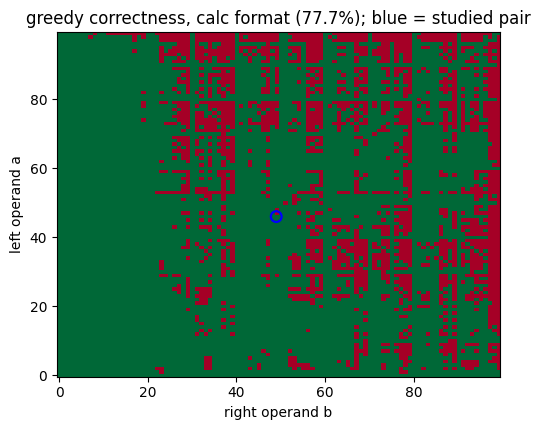

In [2]:
correct, _pred = A.accuracy_grid(model, tokenizer, A_VALS, B_VALS, style="calc")
acc_calc = float(correct.mean())
print(f"accuracy[calc] = {acc_calc:.1%}")
STYLE = "calc"
if acc_calc < 0.5:  # paper-format fallback (not needed for 4b)
    correct, _pred = A.accuracy_grid(model, tokenizer, A_VALS, B_VALS, style="chat")
    STYLE = "chat"
    print(f"accuracy[chat] = {float(correct.mean()):.1%} -> falling back to chat format")
np.save(OUT / f"accuracy_{STYLE}.npy", correct)

class69 = np.mean(
    [correct[a, b] for a in range(100) for b in range(100) if a % 10 == 6 and b % 10 == 9]
)
print(f"_6+_9 class accuracy: {class69:.1%}; correct[36,59] = {bool(correct[36, 59])}")
A0, B0, switched = A.pick_studied_pair(36, 59, correct)
print(
    f"studied pair: {A0}+{B0}={A0 + B0}"
    + (
        " (SWITCHED from 36+59 — the model answers the paper's pair incorrectly)"
        if switched
        else ""
    )
)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.imshow(correct, origin="lower", cmap="RdYlGn", aspect="auto", interpolation="nearest")
ax.scatter([B0], [A0], s=60, facecolors="none", edgecolors="blue", linewidths=1.6)
ax.set_xlabel("right operand b")
ax.set_ylabel("left operand a")
ax.set_title(
    f"greedy correctness, {STYLE} format ({float(correct.mean()):.1%}); blue = studied pair"
)
plt.tight_layout()
plt.show()

## A. Attribution graphs — the two per-digit circuits (Fig A2)

`target="first"` attributes the next token after `=` (magnitude digit, expect `9`);
`target="ones"` teacher-forces the leading digit and attributes the ones digit
(expect `5`). Graphs load from the persisted dumps the supernode review audited.

In [3]:
# Attribution graphs for the studied pair (Fig A2's two per-digit circuits). v2
# pipeline: build_supernode_inputs.py persists the pruned graphs once; the notebook
# LOADS those dumps when present, so interventions run against literally the graphs
# the supernode selection/review saw (a fresh node rebuilds identically — bf16
# determinism has held across five A100s). Explorer HTMLs are written by the
# annotate cell at the end of section E, with the supernodes pre-loaded as groups.
SN_INPUTS = artifacts_dir() / "supernode_inputs" / SIZE
_mpath = SN_INPUTS / "manifest.json"
manifest = json.loads(_mpath.read_text()) if _mpath.exists() else None

graphs, answers, ids = {}, {}, {}
for key, target in (("ones", "ones"), ("first", "first")):
    dump = SN_INPUTS / f"graph_{key}.json"
    if manifest is not None and dump.exists():
        graphs[key] = json.loads(dump.read_text())
        answers[key] = manifest["graphs"][key]["answer_token_id"]
        ids[key] = A.addition_input_ids(tokenizer, A0, B0, DEVICE, target=target, style=STYLE)
        assert ids[key].shape[1] == manifest["graphs"][key]["n_tokens"]
        n_feat = sum(1 for n in graphs[key]["nodes"] if n["node_type"] == "feature")
        print(
            f"{key}: loaded dump ({n_feat} feature nodes; built at "
            f"{manifest['graphs'][key].get('node_threshold', 0.8)} prune, git "
            f"{manifest['git']}), answer {tokenizer.decode([answers[key]])!r}"
        )
    else:
        graphs[key], answers[key], ids[key] = A.build_addition_graph(
            model,
            tc,
            tokenizer,
            A0,
            B0,
            target=target,
            style=STYLE,
            size_key=SIZE,
        )
        n_feat = sum(1 for n in graphs[key]["nodes"] if n["node_type"] == "feature")
        print(f"{key}: built ({n_feat} feature nodes), answer {tokenizer.decode([answers[key]])!r}")

ones: loaded dump (1347 feature nodes; built at 0.8 prune, git 9151262), answer '5'


first: loaded dump (1490 feature nodes; built at 0.8 prune, git 9151262), answer '9'


## B. Supernodes — the reviewed artifact (Fig A1/A2's node classes)

All selection lives in `supernodes/addition_4b.json`, emitted by `build_supernodes.py`:
every pruned-graph feature node is scanned and membership is decided by **operand-grid
receptive-field class** over the 10,000-prompt grid (act-ranked, ≤6 members, runners-up
in `overflow`, influence recorded as evidence only, disjointness enforced). Kind-for-kind
vs the paper's graph:

| paper node | ours | note |
|---|---|---|
| `36`, `59` | `input 46/49 (exact)` | `exact-cross(V)` class — fires when either operand IS the value |
| `_6`, `_9` | `input _6`, `input _9` | Qwen3's are coarse multi-pair lattices, not pure stripes |
| `~30`, `~59` | `magnitude ~46`, `~49` | the band pair (steered in §C) |
| `add _9`, `add ~57` | `add function (hunt)` | **effectively negative**: pair-consistent scan yields only junk-labeled candidates |
| wide/narrow magnitude lookup | `magnitude lookup (~46+~49)` | `region(~a,~b)` class, first-digit circuit |
| `_6+_9` | `lookup (6,9-class)` | §D/§E source |
| `sum = _5` | `sum = _5` | §C/§E readout |
| `sum ~92` | `sum ~95 (low precision)` | first-digit readout |
| `sum = _95`, `5_` | — | impossible under digit-split tokenization |

The figure below shows **every reviewed member's operand grid, one supernode per row**
— the membership evidence in one view. (The v1 influence-pool candidate panels are
retired; see git history / `DEVLOG.md`.)

In [4]:
# Operand-digit token positions of the studied pair (used by the §C suppressions).
pos = A.digit_token_positions(tokenizer, ids["ones"], A0, B0)
print(pos)

{'a_digits': [4, 5], 'b_digits': [7, 8], 'eq': [9], 'plus': [6]}


In [5]:
# v2: supernodes are LOADED from the reviewed artifact — grid-evidenced, scan-based
# selection (build_supernodes.py; membership by operand-grid receptive-field class,
# ranked by activation, influence recorded as evidence only). The notebook contains
# no selection logic; edit + re-approve notebooks/supernodes/addition_4b.json to
# change any set.
SN = A.load_supernodes(f"supernodes/addition_{SIZE}.json")
with open(f"supernodes/addition_{SIZE}.json") as _f:
    print(json.load(_f).get("review_log", ""))

sel = {
    "input_6": A.supernode_members(SN["input _6"], with_acts=False),
    "input_9": A.supernode_members(SN["input _9"], with_acts=False),
    "input_mag": A.supernode_members(SN["magnitude ~46"], with_acts=False)
    + A.supernode_members(SN["magnitude ~49"], with_acts=False),
    "lookup": A.supernode_members(SN["lookup (6,9-class)"], with_acts=False),
    "sum": A.supernode_members(SN["sum = _5"], with_acts=False),
}
lowprec = A.supernode_members(SN["sum ~95 (low precision)"], with_acts=False)
donors = A.supernode_members(SN["lookup (9,9) donors"])  # acts = donor-graph values
polymer_lookups = A.supernode_members(SN["polymer-active lookups"])  # acts = ones-moment
for name, sn in SN.items():
    classes = sorted({str(m["evidence"].get("grid_class")) for m in sn["members"]})
    print(f"{name:28s} n={len(sn['members'])} pos={sn['position']!s:6s} classes={classes}")

2026-07-11: grid-principled selection reviewed by delegation (user waived the manual gate); rejections in REJECTED_MEMBERS; all other members approved
input _6                     n=6 pos=5      classes=['lookup(a%10=6,b%10=5)', 'lookup(a%10=6,b%10=6)']
input _9                     n=6 pos=8      classes=['lookup(a%10=4,b%10=9)', 'lookup(a%10=9,b%10=9)']
magnitude ~46                n=2 pos=None   classes=['band-a(~40)', 'band-a(~45)']
magnitude ~49                n=1 pos=None   classes=['band-b(~49)']
lookup (6,9-class)           n=6 pos=final  classes=['lookup(a%10=3,b%10=3)', 'lookup(a%10=3,b%10=9)', 'lookup(a%10=4,b%10=4)', 'lookup(a%10=5,b%10=9)', 'lookup(a%10=6,b%10=6)', 'lookup(a%10=9,b%10=9)']
sum = _5                     n=6 pos=final  classes=['mod10-sum(r5)']
sum ~95 (low precision)      n=4 pos=final  classes=['magnitude-diag']
lookup (9,9) donors          n=6 pos=final  classes=['lookup(a%10=9,b%10=9)']
add function (hunt)          n=2 pos=final  classes=['mod10-b(r9)']
in

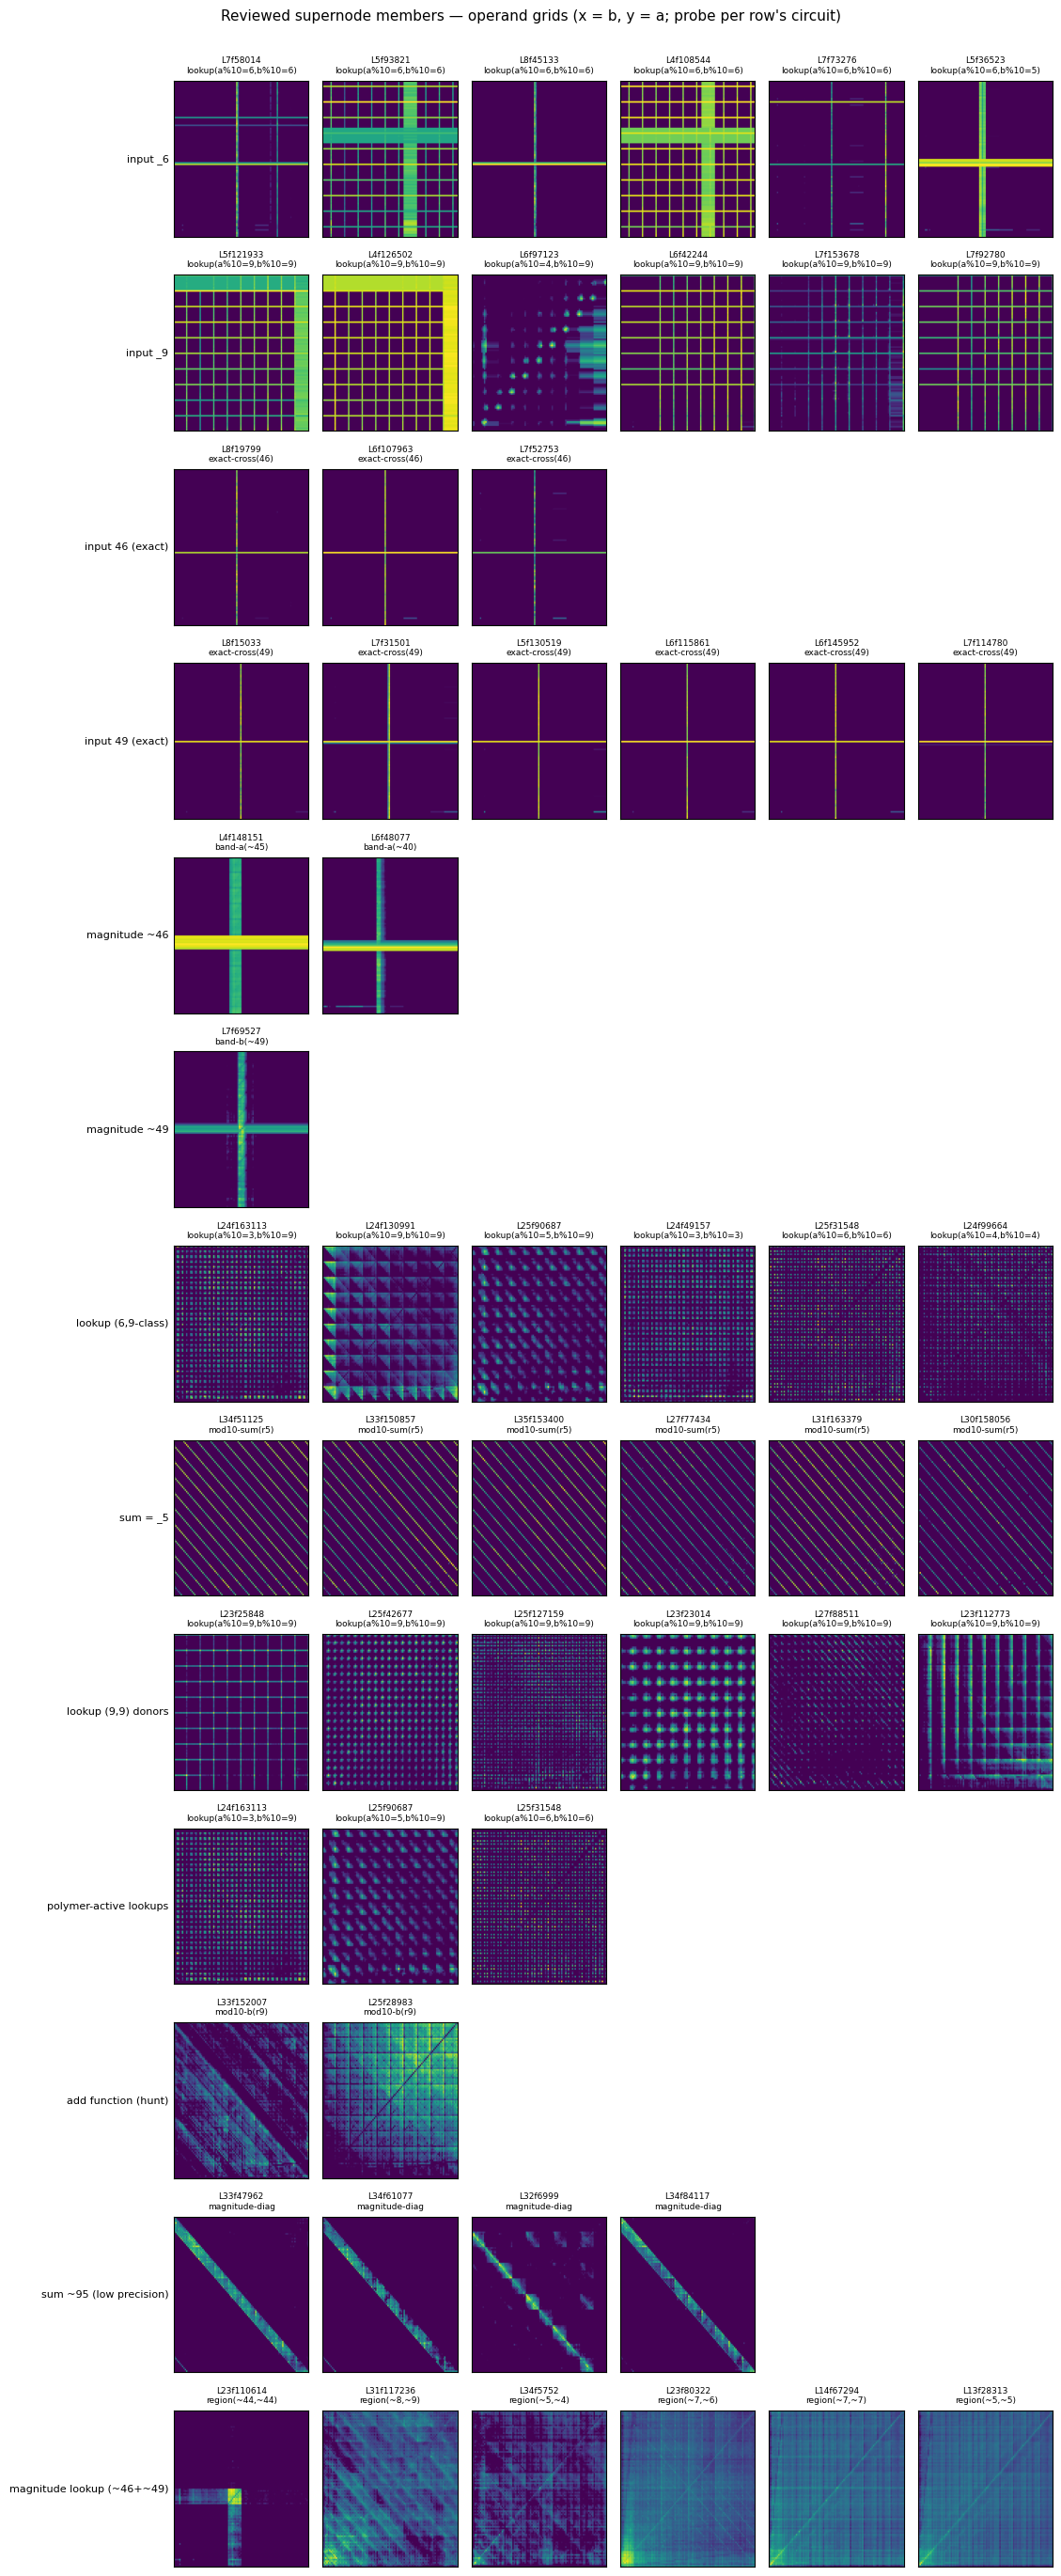

In [6]:
# Operand grids of every REVIEWED supernode member (one supernode per row) — the
# membership evidence in one figure, straight from the persisted evidence pass.
znpz = np.load(SN_INPUTS / "grids.npz")
probe_for = {
    "input _6": "first",
    "input _9": "first",
    "input 46 (exact)": "first",
    "input 49 (exact)": "first",
    "magnitude ~46": "first",
    "magnitude ~49": "first",
    "lookup (6,9-class)": "ones",
    "sum = _5": "ones",
    "lookup (9,9) donors": "ones",
    "polymer-active lookups": "ones",
    "add function (hunt)": "ones",
    "sum ~95 (low precision)": "last",
    "magnitude lookup (~46+~49)": "last",
}
rows = [n for n in probe_for if n in SN and SN[n]["members"]]
ncols = max(len(SN[n]["members"]) for n in rows)
fig, axes = plt.subplots(len(rows), ncols, figsize=(1.9 * ncols, 2.1 * len(rows)), squeeze=False)
for ri, name in enumerate(rows):
    probe = probe_for[name]
    feats = [tuple(int(v) for v in x) for x in znpz[f"{probe}_features"]]
    fidx = {f: i for i, f in enumerate(feats)}
    arr = znpz[f"{probe}_grids"]
    for ci in range(ncols):
        ax = axes[ri][ci]
        if ci >= len(SN[name]["members"]):
            ax.axis("off")
            continue
        m = SN[name]["members"][ci]
        k = (m["layer"], m["feature"])
        if k in fidx:
            ax.imshow(arr[fidx[k]], origin="lower", cmap="viridis", aspect="auto")
        ax.set_title(
            f"L{m['layer']}f{m['feature']}\n{m['evidence'].get('grid_class')}", fontsize=6.5
        )
        ax.set_xticks([])
        ax.set_yticks([])
        if ci == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, ha="right", va="center")
fig.suptitle(
    "Reviewed supernode members — operand grids (x = b, y = a; probe per row's circuit)",
    fontsize=11,
    y=1.002,
)
plt.tight_layout()
plt.savefig(OUT / "grids_supernodes.png", dpi=130, bbox_inches="tight")
plt.show()

## C. Input-supernode suppressions (methods supplement)

Paper (36+59): suppress `_6` → **98** (the ones circuit computes 9+9); suppress `_9` →
**91** ("not 92 — grain of salt"); inhibit the `~30`/`~59` magnitude inputs →
low-precision features suppressed **while the ones path is untouched**.

Per supernode: sweep the patch end layer at the paper's prose strength (−1× ⇒ m=−2),
take the most suppressive ℓ on the clean answer (`5` on the ones graph; `9` on the
first-digit graph for the magnitude pair), then run the full **m=−1/−2/−3** ladder at
that ℓ. Readouts: lookup+sum supernodes (ones graph) and the low-precision supernode
(first-digit graph — the paper's other half); rows at layers ≤ ℓ are pinned and
dropped.

In [7]:
def feats_with_acts(keys, graph_key="ones"):
    by_key = {
        (n["layer"], n["feature_idx"]): float(n.get("activation", 0.0))
        for n in graphs[graph_key]["nodes"]
        if n["node_type"] == "feature"
    }
    return [(L, i, by_key.get((L, i), 0.0)) for L, i in keys]


last = ids["ones"].shape[1] - 1
first_last = ids["first"].shape[1] - 1
readout = [(L, i, last) for L, i in sel["lookup"] + sel["sum"]]
readout_first = [(L, i, first_last) for L, i in lowprec]

interventions_c, ell_choice = {}, {}
for name, keys, p0, metric_graph in [
    ("suppress_6", sel["input_6"], SN["input _6"]["position"], "ones"),
    ("suppress_9", sel["input_9"], SN["input _9"]["position"], "ones"),
    ("inhibit_magnitude", sel["input_mag"], None, "first"),
]:
    ivs = A.steer_interventions(feats_with_acts(keys), m=-2.0, position=p0)
    ell, sweep = A.choose_patch_end_layer(
        model, tc, ids[metric_graph], ivs, answers[metric_graph], mode="suppress"
    )
    ell_choice[name] = {
        "l_max": sweep.end_layers[0],
        "ell": ell,
        "end_layers": sweep.end_layers,
        "probs": [round(p, 4) for p in sweep.probs],
        "baseline_prob": round(sweep.baseline_prob, 4),
    }
    tname = tokenizer.decode([answers[metric_graph]])
    print(
        f"{name}: l_max={sweep.end_layers[0]}, chosen ell={ell} — p({tname!r}) "
        f"{sweep.baseline_prob:.3f} -> {sweep.probs[sweep.end_layers.index(ell)]:.3f} "
        f"at m=-2 on the {metric_graph} graph"
    )
    for m in (-1.0, -2.0, -3.0):
        rep = A.steer_and_report(
            model,
            tc,
            ids["ones"],
            feats_with_acts(keys),
            tokenizer,
            m=m,
            patch_end_layer=ell,
            position=p0,
            readout=readout,
        )
        interventions_c[f"{name}_m{m:g}"] = rep
        ro = {
            k: round(v["pct_of_baseline"], 1)
            for k, v in (rep.get("readout_pct") or {}).items()
            if v["pct_of_baseline"] is not None and not v.get("pinned")
        }
        n_pin = sum(1 for v in (rep.get("readout_pct") or {}).values() if v.get("pinned"))
        print(f"{name} [ell={ell}] m={m:g}: top={rep['steered_top'][:3]}")
        print(f"    ones-path readout above ell ({n_pin} pinned dropped): {ro}")

# The paper's OTHER readout half for the magnitude inhibition: the low-precision
# supernode on the first-digit graph, at the same chosen ell.
ell = ell_choice["inhibit_magnitude"]["ell"]
for m in (-1.0, -2.0, -3.0):
    rep = A.steer_and_report(
        model,
        tc,
        ids["first"],
        feats_with_acts(sel["input_mag"], graph_key="first"),
        tokenizer,
        m=m,
        patch_end_layer=ell,
        position=None,
        readout=readout_first,
    )
    interventions_c[f"inhibit_magnitude_lowprec_m{m:g}"] = rep
    ro = {
        k: round(v["pct_of_baseline"], 1)
        for k, v in (rep.get("readout_pct") or {}).items()
        if v["pct_of_baseline"] is not None and not v.get("pinned")
    }
    n_pin = sum(1 for v in (rep.get("readout_pct") or {}).values() if v.get("pinned"))
    print(
        f"inhibit_magnitude (first-digit graph) [ell={ell}] m={m:g}: top={rep['steered_top'][:3]}"
    )
    print(f"    low-precision readout above ell ({n_pin} pinned dropped): {ro}")
(OUT / "interventions_constrained.json").write_text(
    json.dumps({"ell_choice": ell_choice, "interventions": interventions_c}, indent=1, default=str)
)

suppress_6: l_max=8, chosen ell=16 — p('5') 1.000 -> 0.006 at m=-2 on the ones graph


suppress_6 [ell=16] m=-1: top=[('5', 0.9979), ('4', 0.0006), ('3', 0.0004)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 76.8, 'L24f130991@p10': 99.5, 'L25f90687@p10': 81.2, 'L24f49157@p10': 55.9, 'L25f31548@p10': 71.2, 'L24f99664@p10': 80.7, 'L34f51125@p10': 71.0, 'L33f150857@p10': 71.2, 'L35f153400@p10': 79.3, 'L27f77434@p10': 61.4, 'L31f163379@p10': 72.0, 'L30f158056@p10': 36.9}
suppress_6 [ell=16] m=-2: top=[('3', 0.9291), ('2', 0.0117), ('4', 0.0103)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 42.3, 'L24f130991@p10': 93.6, 'L25f90687@p10': 42.9, 'L24f49157@p10': 0.0, 'L25f31548@p10': 35.4, 'L24f99664@p10': 58.7, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L35f153400@p10': 0.0, 'L27f77434@p10': 0.0, 'L31f163379@p10': 0.0, 'L30f158056@p10': 0.0}


suppress_6 [ell=16] m=-3: top=[('3', 0.5372), ('2', 0.0933), ('1', 0.0933)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 23.8, 'L24f130991@p10': 87.7, 'L25f90687@p10': 28.7, 'L24f49157@p10': 0.0, 'L25f31548@p10': 32.1, 'L24f99664@p10': 62.1, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L35f153400@p10': 0.0, 'L27f77434@p10': 0.0, 'L31f163379@p10': 0.0, 'L30f158056@p10': 0.0}


suppress_9: l_max=7, chosen ell=9 — p('5') 1.000 -> 0.001 at m=-2 on the ones graph
suppress_9 [ell=9] m=-1: top=[('5', 0.9979), ('4', 0.0005), ('3', 0.0004)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 78.6, 'L24f130991@p10': 103.2, 'L25f90687@p10': 81.8, 'L24f49157@p10': 77.4, 'L25f31548@p10': 88.0, 'L24f99664@p10': 66.3, 'L34f51125@p10': 72.4, 'L33f150857@p10': 73.0, 'L35f153400@p10': 78.7, 'L27f77434@p10': 65.6, 'L31f163379@p10': 72.3, 'L30f158056@p10': 45.0}


suppress_9 [ell=9] m=-2: top=[('2', 0.9633), ('1', 0.0176), ('3', 0.0074)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 35.7, 'L24f130991@p10': 84.0, 'L25f90687@p10': 21.6, 'L24f49157@p10': 59.7, 'L25f31548@p10': 34.3, 'L24f99664@p10': 12.6, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L35f153400@p10': 0.0, 'L27f77434@p10': 0.0, 'L31f163379@p10': 0.0, 'L30f158056@p10': 0.0}
suppress_9 [ell=9] m=-3: top=[('2', 0.9673), ('0', 0.0122), ('1', 0.0074)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 39.6, 'L24f130991@p10': 63.9, 'L25f90687@p10': 0.0, 'L24f49157@p10': 38.0, 'L25f31548@p10': 0.0, 'L24f99664@p10': 0.0, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L35f153400@p10': 0.0, 'L27f77434@p10': 0.0, 'L31f163379@p10': 0.0, 'L30f158056@p10': 0.0}


inhibit_magnitude: l_max=7, chosen ell=7 — p('9') 0.562 -> 0.479 at m=-2 on the first graph
inhibit_magnitude [ell=7] m=-1: top=[('5', 0.9991), ('4', 0.0002), ('6', 0.0001)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 100.0, 'L24f130991@p10': 101.1, 'L25f90687@p10': 101.1, 'L24f49157@p10': 100.0, 'L25f31548@p10': 98.5, 'L24f99664@p10': 101.5, 'L34f51125@p10': 100.5, 'L33f150857@p10': 100.0, 'L35f153400@p10': 99.4, 'L27f77434@p10': 101.3, 'L31f163379@p10': 100.0, 'L30f158056@p10': 100.0}


inhibit_magnitude [ell=7] m=-2: top=[('5', 0.9992), ('4', 0.0002), ('6', 0.0001)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 101.2, 'L24f130991@p10': 103.7, 'L25f90687@p10': 102.8, 'L24f49157@p10': 102.1, 'L25f31548@p10': 96.4, 'L24f99664@p10': 103.0, 'L34f51125@p10': 100.0, 'L33f150857@p10': 99.1, 'L35f153400@p10': 97.0, 'L27f77434@p10': 101.3, 'L31f163379@p10': 100.0, 'L30f158056@p10': 100.0}
inhibit_magnitude [ell=7] m=-3: top=[('5', 0.9992), ('4', 0.0002), ('6', 0.0001)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 101.2, 'L24f130991@p10': 105.9, 'L25f90687@p10': 105.1, 'L24f49157@p10': 102.1, 'L25f31548@p10': 96.4, 'L24f99664@p10': 102.3, 'L34f51125@p10': 100.0, 'L33f150857@p10': 99.6, 'L35f153400@p10': 96.3, 'L27f77434@p10': 101.9, 'L31f163379@p10': 100.0, 'L30f158056@p10': 97.7}


inhibit_magnitude (first-digit graph) [ell=7] m=-1: top=[('9', 0.5258), ('?', 0.2192), ('?', 0.0806)]
    low-precision readout above ell (0 pinned dropped): {'L33f47962@p9': 97.0, 'L34f61077@p9': 87.4, 'L32f6999@p9': 89.7, 'L34f84117@p9': 91.5}
inhibit_magnitude (first-digit graph) [ell=7] m=-2: top=[('9', 0.4783), ('?', 0.256), ('?', 0.0831)]
    low-precision readout above ell (0 pinned dropped): {'L33f47962@p9': 90.6, 'L34f61077@p9': 68.4, 'L32f6999@p9': 82.5, 'L34f84117@p9': 78.1}


inhibit_magnitude (first-digit graph) [ell=7] m=-3: top=[('9', 0.422), ('?', 0.2901), ('?', 0.0942)]
    low-precision readout above ell (0 pinned dropped): {'L33f47962@p9': 81.1, 'L34f61077@p9': 41.6, 'L32f6999@p9': 76.3, 'L34f84117@p9': 56.5}


29968

## D. Negative steering: lookup vs sum (paper −2× ⇒ m=−3)

Paper: steering the `_6+_9` lookups at −2× "smears the result over a range of 5"; the
`sum=_95` feature smears "a wider band". No mod-100 sum exists under digit-split, so
the sum side is the `sum = _5` supernode and smear is read on the ones-digit
distribution (`width` = participation ratio: 1 = one confident digit, 10 = uniform).
ℓ swept at m=−3, most suppressive on the clean answer.

In [8]:
steer = {}
for name in ("lookup", "sum"):
    ivs = A.steer_interventions(feats_with_acts(sel[name]), m=-3.0, position=last)
    ell, sweep = A.choose_patch_end_layer(
        model, tc, ids["ones"], ivs, answers["ones"], mode="suppress"
    )
    rep = A.steer_and_report(
        model,
        tc,
        ids["ones"],
        feats_with_acts(sel[name]),
        tokenizer,
        m=-3.0,
        patch_end_layer=ell,
        position=last,
    )
    steer[name] = rep | {"ell": ell, "l_max": sweep.end_layers[0]}
    print(
        f"steer[{name}] m=-3 [l_max={sweep.end_layers[0]}, ell={ell}]: "
        f"width {rep['baseline_digits']['width']:.2f} -> {rep['steered_digits']['width']:.2f}; "
        f"top {rep['steered_top'][:3]}"
    )
    print(f"    steered digit probs: {rep['steered_digits']['digit_probs']}")
(OUT / "steer_compare.json").write_text(json.dumps(steer, indent=1, default=str))

steer[lookup] m=-3 [l_max=25, ell=25]: width 1.00 -> 1.38; top [('1', 0.8397), ('7', 0.1288), ('9', 0.0057)]
    steered digit probs: {'0': 0.0057, '1': 0.8397, '2': 0.0027, '3': 0.0034, '4': 0.003, '5': 0.0018, '6': 0.0024, '7': 0.1288, '8': 0.0034, '9': 0.0057}


steer[sum] m=-3 [l_max=35, ell=35]: width 1.00 -> 5.26; top [('1', 0.3067), ('3', 0.2108), ('2', 0.1642)]
    steered digit probs: {'0': 0.047, '1': 0.3067, '2': 0.1642, '3': 0.2108, '4': 0.1128, '5': 0.0, '6': 0.0135, '7': 0.0415, '8': 0.0222, '9': 0.0775}


2157

## E. The Polymer citation: reuse, suppression, and the lookup swap (Fig A4/A5)

Paper: the `_6+_9` lookup that adds 36+59 also fires on "K. Whang, etc. Polymer, 36,
837, 1" (volume 36 + founding year 1959 → 1995); suppressing it at −2× knocks 995→997;
swapping it for `_9+_9` gives 998. Under digit-split the lookup fires only at the
citation's **ones moment** (`…, 199` → `5`); the bare prompt is a magnitude moment.

Two runs: **(1)** Fig A5 panel 2 — suppress the `polymer-active lookups` supernode only
(m=−3), `sum = _5` supernode as readout (the weak-direct / strong-indirect claim);
**(2)** panel 3 — swap them for the `lookup (9,9) donors` (flip m=−2; donors injected
at +1× their stored donor-graph acts), ℓ swept on the promote-`8` metric with the full
p(`8`)-by-ℓ curve printed.

In [9]:
dev = next(model.parameters()).device
pids = A.tokenize_raw(tokenizer, A.POLYMER_PROMPT, dev)
with torch.no_grad():
    out_g = model.generate(
        pids,
        attention_mask=torch.ones_like(pids),
        max_new_tokens=4,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
print(
    f"completion: {tokenizer.decode(out_g[0, pids.shape[1] :], skip_special_tokens=True)!r} (paper: '995')"
)

pdump = SN_INPUTS / "graph_polymer.json"
if manifest is not None and pdump.exists():
    pg = json.loads(pdump.read_text())
    print(
        f"polymer graph: loaded dump ({sum(1 for n in pg['nodes'] if n['node_type'] == 'feature')} feature nodes)"
    )
else:
    pg, _p_aid, _ = A.build_graph_raw(
        model, tc, tokenizer, A.POLYMER_PROMPT, size_key=SIZE, title="polymer citation"
    )

probe_feats = sel["lookup"] + sel["sum"]
polymer_probe = {}
for tag, prompt in [("bare", A.POLYMER_PROMPT), ("ones", A.POLYMER_PROMPT + "99")]:
    acts, active, ids_p = A.probe_features_on_prompt(model, tc, tokenizer, probe_feats, prompt)
    polymer_probe[tag] = {"activations": acts, "n_active": len(active)}
    print(
        f"[{tag}] {len(active)}/{len(probe_feats)} calc lookup/sum features active at the final position"
    )
    if tag == "ones":
        ones_ids = ids_p
        for k, v in acts.items():
            print(f"    {k}: final={v['final']}")
(OUT / "polymer_probe.json").write_text(
    json.dumps(polymer_probe, indent=1, ensure_ascii=False, default=str)
)

completion: '995.\n' (paper: '995')
polymer graph: loaded dump (162 feature nodes)
[bare] 0/12 calc lookup/sum features active at the final position


[ones] 9/12 calc lookup/sum features active at the final position
    L24f163113: final=12.375
    L24f130991: final=0.0
    L24f49157: final=0.0
    L24f99664: final=0.0
    L25f90687: final=18.5
    L25f31548: final=18.25
    L27f77434: final=14.438
    L30f158056: final=18.0
    L31f163379: final=11.562
    L33f150857: final=47.0
    L34f51125: final=73.0
    L35f153400: final=13.312


2913

In [10]:
from llm_circuits.circuits.interventions import FeatureIntervention, run_feature_intervention

plast = ones_ids.shape[1] - 1
readout_sums = [(L, i, plast) for L, i in sel["sum"]]

# Fig A5 panel 2 (paper-faithful): suppress the polymer-active lookups ONLY at m=-3,
# reading out the sum supernode — constrained at the ell most suppressive of the year
# digit.
ivs_s = A.steer_interventions(polymer_lookups, m=-3.0, position=plast)
ell_s, sweep_s = A.choose_patch_end_layer(
    model, tc, ones_ids, ivs_s, answers["ones"], mode="suppress"
)
rep_lk = A.steer_and_report(
    model,
    tc,
    ones_ids,
    polymer_lookups,
    tokenizer,
    m=-3.0,
    patch_end_layer=ell_s,
    position=plast,
    readout=readout_sums,
)
ro_lk = {
    k: round(v["pct_of_baseline"], 1)
    for k, v in (rep_lk.get("readout_pct") or {}).items()
    if v["pct_of_baseline"] is not None and not v.get("pinned")
}
n_pin = sum(1 for v in (rep_lk.get("readout_pct") or {}).values() if v.get("pinned"))
print(
    f"suppress the {len(polymer_lookups)} polymer-active lookups @ m=-3 "
    f"[l_max={sweep_s.end_layers[0]}, ell={ell_s}]: "
    f"{rep_lk['baseline_top'][:2]} -> {rep_lk['steered_top'][:3]}"
)
print(f"    sum-supernode readout above ell ({n_pin} pinned dropped): {ro_lk}")
(OUT / "polymer_suppression_constrained.json").write_text(
    json.dumps(rep_lk | {"ell": ell_s, "l_max": sweep_s.end_layers[0]}, indent=1, default=str)
)

# Fig A5 panel 3: swap (6,9)-class lookups -> the grid-verified (9,9) donors. Flip at
# the paper's -1x (m=-2); donors injected at +1x their stored donor-graph activation.
# ell chosen on the promote-'8' metric; the full p('8')-by-ell curve is the decision.
ans8 = (
    manifest["graphs"]["donor99"]["answer_token_id"]
    if manifest is not None
    else A.build_addition_graph(
        model, tc, tokenizer, 49, 49, target="ones", style=STYLE, size_key=SIZE
    )[1]
)
print(f"swap target token: {tokenizer.decode([ans8])!r} (expect '8')")
ivs = A.steer_interventions(polymer_lookups, m=-2.0, position=plast) + [
    FeatureIntervention(L, i, position=plast, value=a) for (L, i, a) in donors
]
ell_sw, sweep_sw = A.choose_patch_end_layer(model, tc, ones_ids, ivs, ans8, mode="promote")
print(
    "lookup swap p('8') by patch end layer: "
    + ", ".join(f"{L}:{p:.3f}" for L, p in zip(sweep_sw.end_layers, sweep_sw.probs, strict=True))
)
res_c = run_feature_intervention(
    model, tc, ones_ids, ivs, n_bos_tokens=A.N_BOS, patch_end_layer=ell_sw
)
print(
    f"lookup swap (6,9)->(9,9) [l_max={sweep_sw.end_layers[0]}, ell={ell_sw}]: "
    f"{A.top_tokens(res_c.baseline_logits[-1], tokenizer)[:2]} -> "
    f"{A.top_tokens(res_c.ablated_logits[-1], tokenizer)[:3]}  (paper: 995 -> 998)"
)
(OUT / "lookup_swap.json").write_text(
    json.dumps(
        {
            "suppressed": polymer_lookups,
            "donors": donors,
            "ell": ell_sw,
            "l_max": sweep_sw.end_layers[0],
            "end_layers": sweep_sw.end_layers,
            "p8_by_ell": [round(p, 4) for p in sweep_sw.probs],
            "baseline_top": A.top_tokens(res_c.baseline_logits[-1], tokenizer),
            "swapped_top": A.top_tokens(res_c.ablated_logits[-1], tokenizer),
        },
        indent=1,
        ensure_ascii=False,
        default=str,
    )
)

suppress the 3 polymer-active lookups @ m=-3 [l_max=25, ell=25]: [('5', 0.9824), ('4', 0.0066)] -> [('1', 0.8315), ('9', 0.0876), ('4', 0.0152)]
    sum-supernode readout above ell (0 pinned dropped): {'L34f51125@p22': 0.0, 'L33f150857@p22': 0.0, 'L35f153400@p22': 0.0, 'L27f77434@p22': 0.0, 'L31f163379@p22': 0.0, 'L30f158056@p22': 0.0}
swap target token: '8' (expect '8')


lookup swap p('8') by patch end layer: 27:0.046, 28:0.040, 29:0.063, 30:0.047, 31:0.067, 32:0.046, 33:0.015, 34:0.011, 35:0.015
lookup swap (6,9)->(9,9) [l_max=27, ell=31]: [('5', 0.9824), ('4', 0.0066)] -> [('1', 0.2659), ('4', 0.1256), ('7', 0.1108)]  (paper: 995 -> 998)


933

In [11]:
# Re-render the explorer HTMLs with the REVIEWED supernodes pre-loaded as GROUPS.
from llm_circuits.circuits.graph_explorer import render_graph_explorer_html

gdump = SN_INPUTS / "graph_donor99.json"
if manifest is not None and gdump.exists():
    g99 = json.loads(gdump.read_text())
else:
    g99 = A.build_addition_graph(
        model, tc, tokenizer, 49, 49, target="ones", style=STYLE, size_key=SIZE
    )[0]


def _grp(*names):
    return [
        {
            "name": n,
            "members": A.supernode_members(SN[n], with_acts=False),
            "position": SN[n]["position"],
        }
        for n in names
    ]


html_jobs = {
    "graph_46p49_ones.html": (
        graphs["ones"],
        "46+49 ones",
        _grp(
            "input _6",
            "input _9",
            "magnitude ~46",
            "magnitude ~49",
            "lookup (6,9-class)",
            "sum = _5",
        ),
    ),
    "graph_46p49_first.html": (
        graphs["first"],
        "46+49 first digit",
        _grp(
            "magnitude ~46",
            "magnitude ~49",
            "sum ~95 (low precision)",
            "magnitude lookup (~46+~49)",
        ),
    ),
    "graph_49p49_ones.html": (g99, "49+49 ones (donor graph)", _grp("lookup (9,9) donors")),
    "graph_polymer.html": (pg, "polymer citation (bare prompt)", []),
}
for fname, (gd, ttl, gset) in html_jobs.items():
    render_graph_explorer_html(gd, OUT / fname, title=ttl, groups=gset)
    print(f"annotated {fname}: {len(gset)} groups")

annotated graph_46p49_ones.html: 6 groups


annotated graph_46p49_first.html: 4 groups


annotated graph_49p49_ones.html: 1 groups
annotated graph_polymer.html: 0 groups


## F. Intermediate computation: `assert (4 + 5) * 3 ==` (Fig A6)

Paper: completes 27 with a "computed 9" intermediate feature (flagged
not-the-final-answer; the paper hedges the suppressive mechanism). We check the
completion, then screen every graph feature by its **demeaned unembedding weight on
"9"** most-negative-first — the paper's computed-9 signature is a *negative* direct
effect, which a top-logit scan cannot find by construction.

In [12]:
iid = A.tokenize_raw(tokenizer, A.INTERMEDIATE_PROMPT, dev)
with torch.no_grad():
    out_g = model.generate(
        iid,
        attention_mask=torch.ones_like(iid),
        max_new_tokens=4,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
print(
    f"completion: {tokenizer.decode(out_g[0, iid.shape[1] :], skip_special_tokens=True)!r} (paper: '27')"
)
ig, i_aid, _ = A.build_graph_raw(
    model,
    tc,
    tokenizer,
    A.INTERMEDIATE_PROMPT,
    size_key=SIZE,
    out_html=str(OUT / "graph_intermediate.html"),
    title="(4+5)*3",
)
nine = [
    n
    for n in ig["nodes"]
    if n["node_type"] == "feature"
    and any("9" in str(t) for t in ((n.get("label") or {}).get("top_logits") or [])[:5])
]
nine.sort(key=lambda n: -n.get("influence", 0))
for n in nine[:6]:
    print(
        f"  '9'-logit feature L{n['layer']}f{n['feature_idx']}@p{n['position']} "
        f"influence={n.get('influence', 0):.4f} top={(n.get('label') or {}).get('top_logits', [])[:5]}"
    )
if not nine:
    print("  no '9'-logit features in the pruned graph")

# Recheck F6: the top-logit scan above is structurally blind to the paper's mechanism —
# its "computed 9, intermediate step" feature is DEFINED by the strongest NEGATIVE direct
# output effect on "9". Screen every feature node in the graph by its demeaned
# unembedding weight on the "9" token (through the final-norm scale), most-negative-first.
nine_id = int(tokenizer("9", add_special_tokens=False).input_ids[0])
feat_nodes = [n for n in ig["nodes"] if n["node_type"] == "feature"]
w9 = A.direct_token_weights(
    model, tc, sorted({(n["layer"], n["feature_idx"]) for n in feat_nodes}), nine_id
)
final_pos = iid.shape[1] - 1
by_feat = {}
for n in feat_nodes:  # one row per feature; prefer its final-position instance
    key = (n["layer"], n["feature_idx"])
    cur = by_feat.get(key)
    rank = (n["position"] == final_pos, n.get("influence", 0.0))
    if cur is None or rank > (cur["position"] == final_pos, cur.get("influence", 0.0)):
        by_feat[key] = n
ranked = sorted(by_feat, key=lambda k: w9[k])
print(
    f"\nmost-negative direct '9' weights ({len(by_feat)} graph features; final position p{final_pos}):"
)
for key in ranked[:8]:
    n = by_feat[key]
    print(
        f"  L{key[0]}f{key[1]}@p{n['position']} w9={w9[key]:+.3f} "
        f"influence={n.get('influence', 0):.4f} act={n.get('activation', 0.0):.2f} "
        f"top={((n.get('label') or {}).get('top_logits') or [])[:4]}"
    )
w9_sorted = sorted(w9.values())
print(
    f"w9 distribution: min {w9_sorted[0]:+.3f} / median {w9_sorted[len(w9_sorted) // 2]:+.3f} / "
    f"max {w9_sorted[-1]:+.3f}"
)
(OUT / "computed9_screen.json").write_text(
    json.dumps(
        [
            {
                "layer": k[0],
                "feature": k[1],
                "position": by_feat[k]["position"],
                "w9": round(w9[k], 4),
                "influence": by_feat[k].get("influence", 0.0),
                "top_logits": ((by_feat[k].get("label") or {}).get("top_logits") or [])[:5],
            }
            for k in ranked[:12]
        ],
        indent=1,
        ensure_ascii=False,
        default=str,
    )
)

completion: ' 27\n' (paper: '27')


[07/11/26 19:38:22] INFO     Selected 1 logits with cumulative probability 0.9727

/teamspace/studios/this_studio/llm-circuits/src/llm_circuits/circuits/attribution_graph.py:486: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  prob=float(top_p[rank]),  # actual prob (influence seed; sums to ~desired_prob)


                    INFO     Built 8409 nodes (emb=12, feat=8000, err=396, logit=1)

                    INFO     Pre-computing source contribution vectors ...

...

                    INFO     Downloading feature file layer_35.bin from mwhanna/qwen3-4b-transcoders ...

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

                    WARNING  Failed to load label for layer 35 feature 154698: No gzip magic found in feature blob 
                             at index 154698

  '9'-logit feature L33f124683@p11 influence=0.0025 top=['5', '1', '3', '9', '0']
  '9'-logit feature L26f155482@p11 influence=0.0019 top=['7', '9', '2', '1', ' ']
  '9'-logit feature L31f131410@p3 influence=0.0004 top=['6', '个', ' years', '9', '0']

most-negative direct '9' weights (1137 graph features; final position p11):
  L30f12843@p11 w9=-0.388 influence=0.0009 act=1.53 top=[' Yay', 'ija', 'ADR', '四周']
  L31f4652@p4 w9=-0.303 influence=0.0007 act=26.12 top=['ham', 'ern', '-', '_']
  L32f149033@p11 w9=-0.272 influence=0.0156 act=22.12 top=['穿戴', ' <![', ' Slut', 'iability']
  L28f8524@p11 w9=-0.271 influence=0.0004 act=2.02 top=[')",', "}',", '}",', ")',"]
  L0f158266@p6 w9=-0.222 influence=0.0016 act=1.70 top=['dorf', 'agara', ' ${⏎', 'деся']
  L12f118161@p4 w9=-0.199 influence=0.0005 act=2.86 top=['.exports', 'inea', 'lete', 'ubes']
  L4f43637@p6 w9=-0.176 influence=0.0010 act=2.62 top=['↘', '大家一起', ' \u200b\u200b', '-HT']
  L34f8628@p5 w9=-0.173 influence=0.0008 act=47.25 top=[

2283

## G. Introspection dialogue

Paper: asked "Briefly, how did you get that?", Haiku narrates the schoolbook carry
algorithm — which its circuits do not implement ("Apparently not!").
One greedy shot cannot support "carry narration is absent": the dialogue is also
sampled (6 question phrasings × 2 seeds, T=0.7) and screened for carry vocabulary.


In [13]:
d = A.introspection_dialogue(model, tokenizer, A0, B0)
print(f"Q: Answer in one word. What is {A0}+{B0}?")
print(f"A: {d['answer']!r}")
print("Q: Briefly, how did you get that?")
print(f"A: {d['explanation']!r}")
(OUT / "introspection.json").write_text(json.dumps(d, indent=1, ensure_ascii=False))

# Robustness: sampled explanations over question phrasings — does carry narration EVER
# appear? (Haiku narrates the schoolbook carry algorithm it does not mechanistically use.)
QUESTIONS = [
    "Briefly, how did you get that?",
    "Explain step by step how you computed it.",
    "How did you add those two numbers? Be brief.",
    "Describe the method you used to get the answer.",
    "Walk me through your mental arithmetic.",
    "What procedure did you follow to compute the sum?",
]
CARRY_WORDS = (
    "carry",
    "carried",
    "carrying",
    "regroup",
    "column",
    "ones digit",
    "units digit",
    "tens digit",
    "ones place",
    "units place",
    "tens place",
    "add the tens",
    "added the tens",
    "add the ones",
    "added the ones",
)
samples = []
for qi, q in enumerate(QUESTIONS):
    for s in range(2):
        torch.manual_seed(1000 + 10 * qi + s)
        d2 = A.introspection_dialogue(
            model, tokenizer, A0, B0, how_question=q, do_sample=True, temperature=0.7
        )
        hits = [w for w in CARRY_WORDS if w in d2["explanation"].lower()]
        samples.append(
            {
                "question": q,
                "seed": 1000 + 10 * qi + s,
                "explanation": d2["explanation"],
                "carry_words": hits,
            }
        )
        tag = f"CARRY {hits}" if hits else "no-carry"
        print(f"[{qi}.{s}] {tag}: {d2['explanation'][:90]!r}")
n_carry = sum(1 for x in samples if x["carry_words"])
print(f"\nschoolbook-algorithm narration in {n_carry}/{len(samples)} sampled explanations")
(OUT / "introspection_samples.json").write_text(json.dumps(samples, indent=1, ensure_ascii=False))

Q: Answer in one word. What is 46+49?
A: '95'
Q: Briefly, how did you get that?
A: 'I added 46 and 49 together: 46 + 49 = 95.'


[0.0] no-carry: 'I added 46 and 49 together: 46 + 49 = 95.'


[0.1] no-carry: 'I added 46 and 49 together: 46 + 49 = 95.'


[1.0] CARRY ['ones place', 'tens place', 'add the tens', 'add the ones']: "Sure! Let's compute 46 + 49 step by step:\n\n1. **Add the tens place**:  \n   40 + 40 = 80\n\n2"


[1.1] CARRY ['add the tens', 'add the ones']: "Sure! Let's compute 46 + 49 step by step:\n\n1. Start with the first number: **46**.\n2. Add "


...

[4.0] CARRY ['add the tens', 'add the ones']: "Sure! Let's walk through the addition of 46 and 49 step by step:\n\n1. **Add the tens**: 40 "


[4.1] CARRY ['add the tens']: "Sure! Let's go through the addition step by step:\n\n**46 + 49**\n\nFirst, break it down into "


[5.0] no-carry: 'Addition.'


[5.1] no-carry: 'Addition.'

schoolbook-algorithm narration in 6/12 sampled explanations


3018

## H. Dataset examples of the lookup/sum features (Fig A3)

Paper: the `_6+_9` lookup feature fires on non-arithmetic surface forms — citations,
financial tables, dates. We scan 2,000 streamed C4 documents (network needed) for the top
lookup and sum features.

In [14]:
feats = [tuple(k) for k in sel["lookup"][:3] + sel["sum"][:3]]
texts = A.stream_c4_texts(2000)
hits = A.corpus_scan(model, tc, feats, texts, tokenizer)
for (L, i), h in hits.items():
    print(f"=== L{L}f{i}")
    for act, snip in h[:4]:
        print(f"  {act:7.2f}  {snip[:110]!r}")
(OUT / "corpus_examples.json").write_text(
    json.dumps(
        {f"L{L}f{i}": [(round(v, 2), s) for v, s in h] for (L, i), h in hits.items()},
        indent=1,
        ensure_ascii=False,
    )
)

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

=== L24f163113
    22.88  'olinguals. Total users in all countries: 1⟦,⟧016,650'
    15.69  ' templates, media/file descriptions, and primary meta-pages.\n2⟦0⟧19-04-'
    13.50  '1935 – April 25, 2⟦0⟧10) was an American singer'
    13.38  ' is my previous term CST8207 Fall 2⟦0⟧12.\nThis is a Mobile'
=== L24f130991
    30.00  ' x 39.0"\nSize including frame: ⟦3⟧6.0" x 4'
    29.75  ' Cabinet Pull - Light Bronze.\nTop Knobs Aspen Twig ⟦1⟧2 Inch CC Cabinet Pull - Light'
    27.62  '9pm.\nPrince’s Foundation Gallery, 19-⟦2⟧2 Charlotte Road, Hoxton'
    22.62  '5pm Thursday 18th and re-open Tues ⟦2⟧3rd 8.30'
=== L25f90687
    15.06  'WHAT: This 6 day,⟦ ⟧5 night retreat includes an exciting three'
    13.69  ' systems installed across the UK and beyond. In November 2⟦0⟧14, Vysionics'
    12.38  ' 1st of November with a preview evening on October ⟦2⟧4th from 6-9'
    12.31  ' filed under Uncategorized.\nPosted March 5th, 2⟦0⟧14 by Scott Coatsworth'
=== L34f51125
   172.00  ' size is approxima

5932

## Summary — verdicts vs the paper

Constrained patching throughout (ℓ swept, stated per row); supernodes from the
reviewed artifact. v1 (propagate-mode) history: `DEVLOG.md`.

| Paper (Claude 3.5 Haiku) | This run (Qwen3-4B, 46+49) | Verdict |
|---|---|---|
| `calc:` competence | 77.7% on the 10k grid; 36+59 wrong → pair switched to 46+49 | **partial** |
| Two-pathway graph (Fig A2) | first-digit graph → `9` (1490 feats), ones graph → `5` (1347) | **reproduced** (digit-split) |
| Node taxonomy (Fig A1/A2) | kind-for-kind table + evidence figure in §B: exact crosses, input lattices, band pair, lookups, r5 sums, low-precision sums, magnitude-lookup regions all present. Absent: add-function (pair-consistent scan → 2 junk-labeled candidates, **effectively negative**) and mod-100 sums (tokenization) | **reproduced** (adapted; two documented absences) |
| Suppress `_6` → 98 | [ℓ=16] ablation inert (`5` @ 0.998); −1× → **`3` @ 0.929**; −2× → `3` @ 0.537. Sums → 0% from −1×; lookups partial (resilient L24f130991 at 94%) | **reproduced at paper strength** (crisp substitution; the 9+9→`8` numerology was propagate-only — and the paper warns on numerology) |
| Suppress `_9` → 91 | [ℓ=9] ablation inert; −1× → **`2` @ 0.963**; −2× → `2` @ 0.967. Sums → 0% from −1× | **reproduced at paper strength** |
| Inhibit `~30`/`~59` magnitude | [ℓ=7, band pair] ones `5` @ 0.999 at **every** strength (readouts 96–106%); first digit 0.526 / 0.478 / 0.422 with low-precision readouts 87–97 / 68–91 / **42–81%** | **reproduced** (the dissociation at full paper strength; magnitude side graded, not Haiku's collapse) |
| Neg-steer lookup (~5-wide smear) vs sum (wider) | lookup [ℓ=25]: flips `1` @ 0.84 (width 1.38); sum [ℓ=35]: **smears, width 5.26** (`1` .31 / `3` .21 / `2` .16 / `4` .11) | **partial** (sum-side smear matches; lookup side flips) |
| Polymer completes 995 @ 98.6% | `995.`; ones moment `5` @ 0.982 | **reproduced** |
| Polymer reuse of `_6+_9` | 9/12 reviewed lookup/sum members active at the ones moment; 0/12 at the bare prompt | **reproduced** |
| Polymer −2× suppression → 997 | lookups-only [ℓ=25]: `5` @ 0.982 → **`1` @ 0.83**, all six sum readouts **0%** | **reproduced** (weak-direct / strong-indirect, protocol-exact) |
| Lookup swap → 998 @ 66.6% | 3 active lookups flipped (m=−2) + six grid-verified (9,9) donors at +1×: **p(`8`) ≤ 0.067 at every ℓ ∈ [27, 35]** (best ℓ=31 → `1` @ 0.27) | **not reproduced under the paper's protocol** — selection, donor purity and protocol all controlled ⇒ a model difference: Qwen3's swap route needs the within-range recompute pinning forbids (v1 propagate landed `8` @ 0.715; DEVLOG) |
| Intermediate `(4+5)*3` → 27 + computed-9 | ` 27` ✓; direct-weight screen: no suppressive computed-9 candidate | **partial** |
| Introspection (carry narration) | 6/12 sampled explanations narrate the place-value algorithm the circuits don't implement | **reproduced** |
| Corpus reuse (Fig A3) | lookup/sum members fire on dates, totals, page ranges, prices | **reproduced** |

**Bottom line.** Under the paper's protocol end-to-end, the suppression side of the
addition story transfers cleanly — crisp digit substitutions at the paper's strengths
with the sum stage silenced, the magnitude/ones dissociation at full strength, the
sum-side smear, and a protocol-exact indirect-effect result on the Polymer prompt. The
two sharp divergences: the lookup-side smear never appears, and the donor-injection
swap finds no patch end layer that lands it — a genuine Qwen3-vs-Haiku difference now
that selection style, donor purity, and protocol are all controlled.